<a href="https://colab.research.google.com/github/KiruthikaKrishan2003/Calci/blob/main/Copy_of_IISF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import json, os, torch, cv2, numpy as np, albumentations as A
from PIL import Image; from matplotlib import pyplot as plt
from glob import glob
from torch.utils.data import random_split, Dataset, DataLoader
from albumentations.pytorch import ToTensorV2

class CustomSegmentationDataset(Dataset):

    def __init__(self, root, transformations = None):

        self.im_paths = sorted(glob(f"{root}/*/images/*.jpg"))
        self.gt_paths = sorted(glob(f"{root}/*/masks/*.png"))
        self.transformations = transformations
        self.n_cls = 5

        assert len(self.im_paths) == len(self.gt_paths)

    def __len__(self): return len(self.im_paths)

    def __getitem__(self, idx):

        im, gt = self.get_im_gt(self.im_paths[idx], self.gt_paths[idx])

        if self.transformations: im, gt = self.apply_transformations(im, gt)

        return im, gt

    def get_im_gt(self, im_path, gt_path): return self.read_im(im_path), self.read_im(gt_path)

    def read_im(self, path): return cv2.cvtColor(cv2.imread(path, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    def apply_transformations(self, im, gt): transformed = self.transformations(image = im, mask = gt); return transformed["image"], transformed["mask"]

def get_dls(root, transformations, bs, split=[0.9, 0.05, 0.05]):

    assert sum(split) == 1., "Sum of the split must be exactly 1"

    ds = CustomSegmentationDataset(root=root, transformations=transformations)
    n_cls = ds.n_cls

    total_len = len(ds)
    tr_len = int(total_len * split[0])
    val_len = int(total_len * split[1])
    test_len = total_len - (tr_len + val_len)

    # Data split
    tr_ds, val_ds, test_ds = random_split(ds, [tr_len, val_len, test_len])

    print(f"\nThere are {len(tr_ds)} number of images in the train set")
    print(f"There are {len(val_ds)} number of images in the validation set")
    print(f"There are {len(test_ds)} number of images in the test set\n")

    # Get dataloaders
    tr_dl = DataLoader(dataset=tr_ds, batch_size=bs, shuffle=True, num_workers=8)
    val_dl = DataLoader(dataset=val_ds, batch_size=bs, shuffle=False, num_workers=8)
    test_dl = DataLoader(dataset=test_ds, batch_size=1, shuffle=False, num_workers=8)

    return tr_dl, val_dl, test_dl, n_cls


root = "/content/drive/MyDrive/Semantic segmentation dataset-20240112T050915Z-001/Semantic segmentation dataset"
mean, std, im_h, im_w = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], 256, 256
trans = A.Compose( [A.Resize(im_h, im_w), A.augmentations.transforms.Normalize(mean = mean, std = std), ToTensorV2(transpose_mask = True) ])
tr_dl, val_dl, test_dl, n_cls = get_dls(root = root, transformations = trans, bs = 4)

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.21 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()



There are 64 number of images in the train set
There are 3 number of images in the validation set
There are 5 number of images in the test set



/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


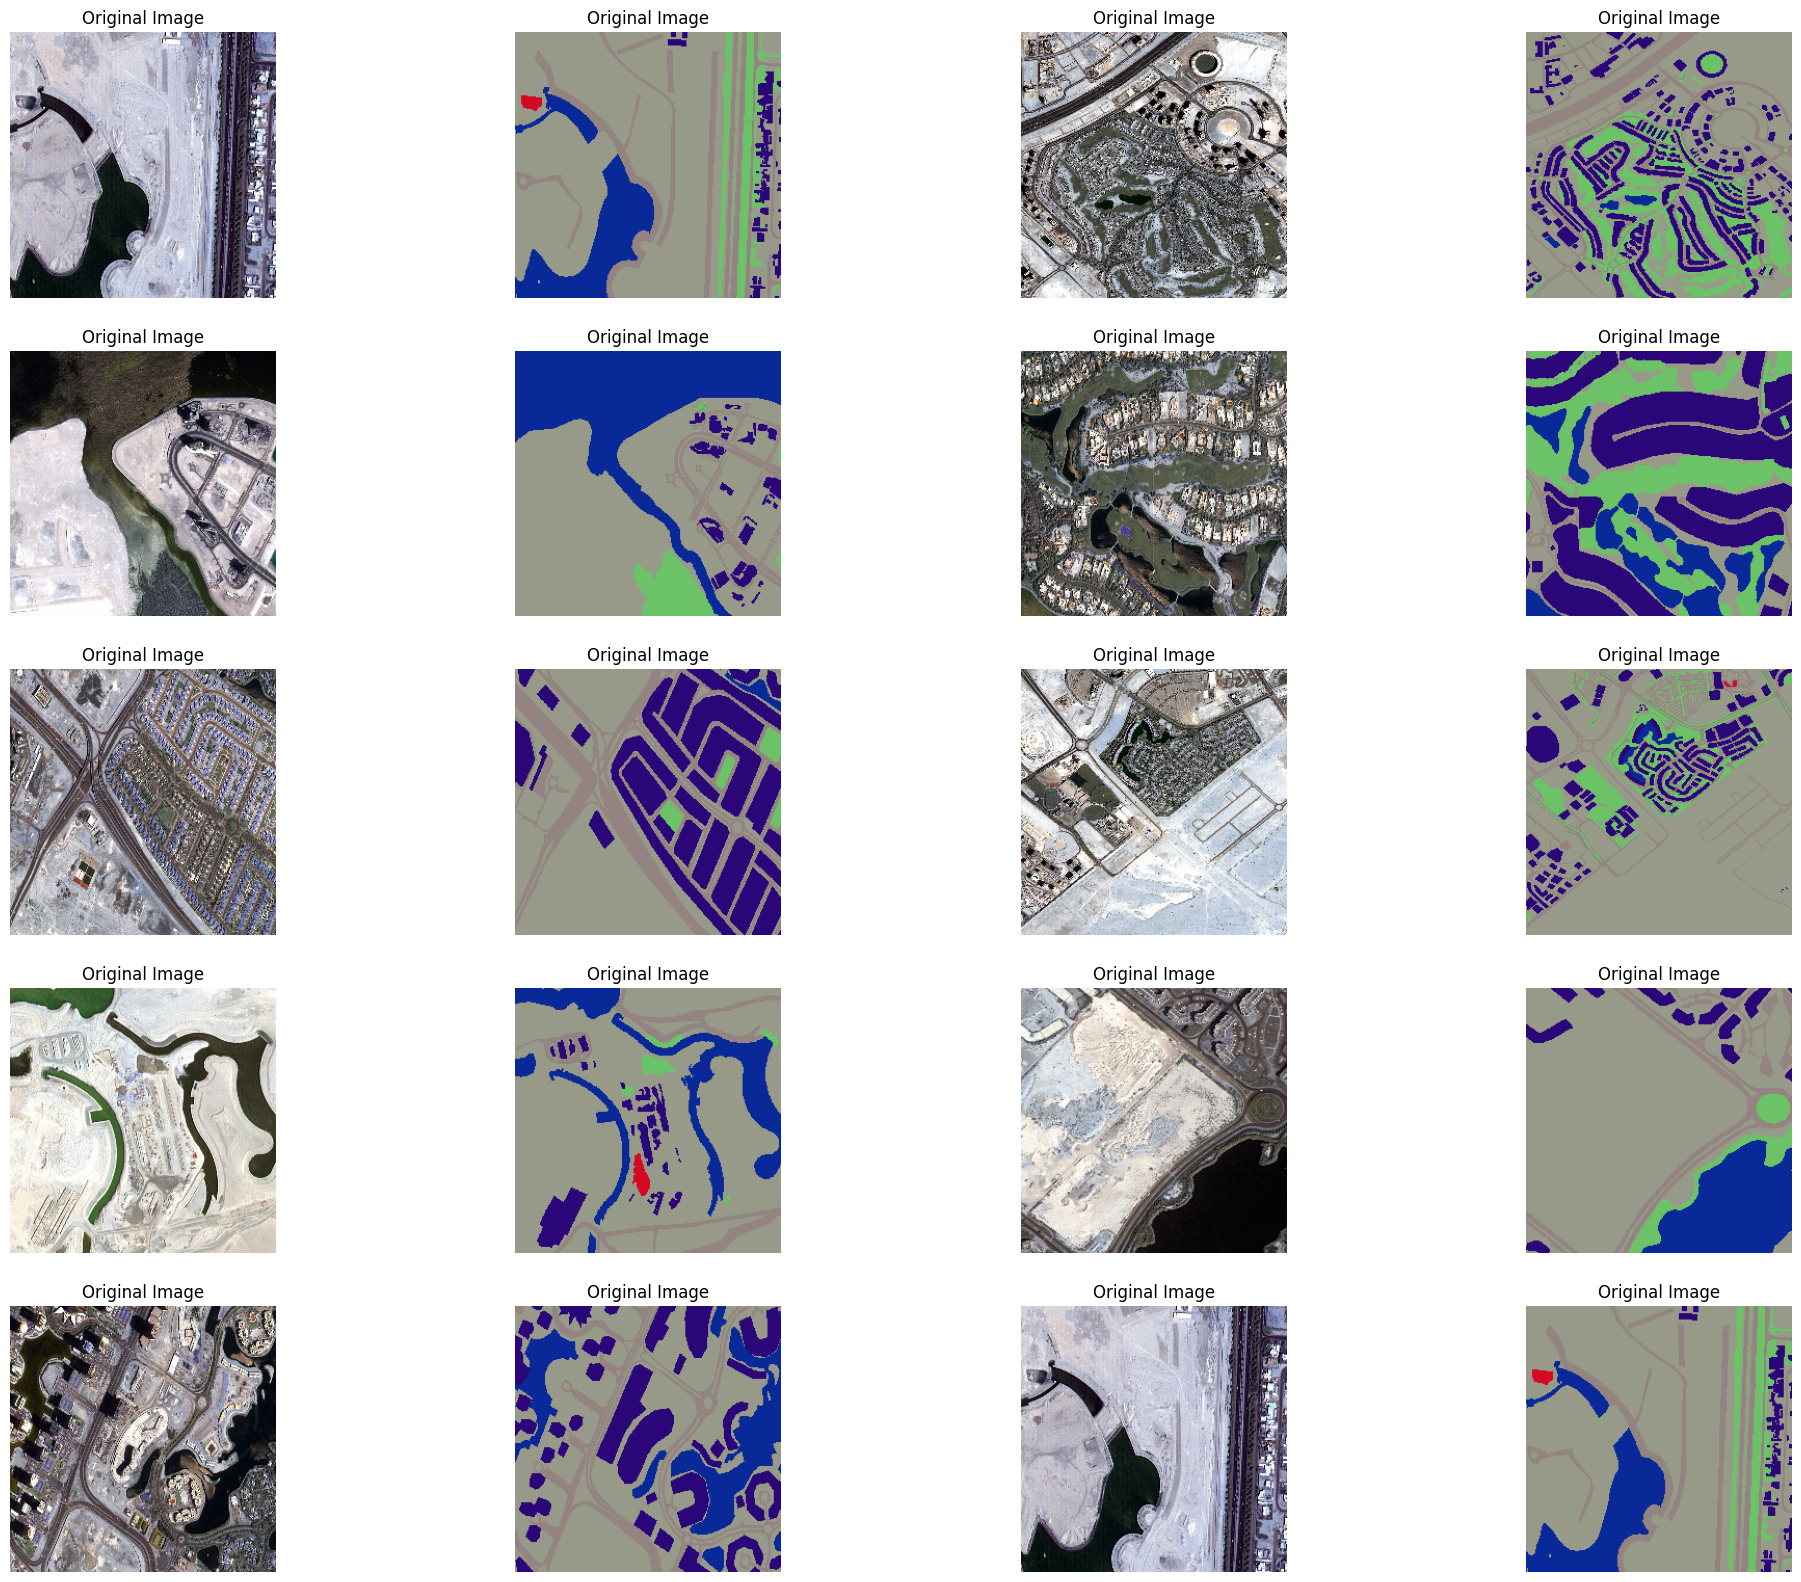

In [ ]:
import random
from torchvision import transforms as tfs

def tn_2_np(t):
    invTrans = tfs.Compose([ tfs.Normalize(mean = [ 0., 0., 0. ], std = [ 1/0.229, 1/0.224, 1/0.225 ]),
                                tfs.Normalize(mean = [ -0.485, -0.456, -0.406 ], std = [ 1., 1., 1. ]) ])

    rgb = True if len(t) == 3 else False

    return (invTrans(t) * 255).detach().cpu().permute(1,2,0).numpy().astype(np.uint8) if rgb else (t*255).detach().cpu().numpy().astype(np.uint8)

def plot(rows, cols, count, im, gt = None, title = "Original Image"):

    plt.subplot(rows, cols, count)
    plt.imshow(tn_2_np(im.squeeze(0).float())) if gt else plt.imshow(tn_2_np(im.squeeze(0)))
    plt.axis("off"); plt.title(title)

    return count + 1

def visualize(ds, n_ims):

    plt.figure(figsize = (25, 20))
    rows = n_ims // 4; cols = n_ims // rows
    count = 1
    indices = [random.randint(0, len(ds) - 1) for _ in range(n_ims)]

    for idx, index in enumerate(indices):

        if count == n_ims + 1: break
        im, gt = ds[index]

        # First Plot
        count = plot(rows, cols, count, im = im)

        # Second Plot
        count = plot(rows, cols, count, im = gt, gt = True)

visualize(tr_dl.dataset, n_ims = 20)

In [ ]:
!pip install segmentation_models_pytorch
import segmentation_models_pytorch as smp

model = smp.DeepLabV3Plus(classes = n_cls)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 3e-2)

import time
from tqdm import tqdm
from torch.nn import functional as F

class Metrics():

    def __init__(self, pred, gt, loss_fn, eps = 1e-10, n_cls = 2):

        self.pred, self.gt = torch.argmax(F.softmax(pred, dim=1), dim = 1), gt # (batch, width, height)
        self.loss_fn, self.eps, self.n_cls, self.pred_ = loss_fn, eps, n_cls, pred

    def to_contiguous(self, inp): return inp.contiguous().view(-1)

    def PA(self):

        with torch.no_grad():
            match = torch.eq(self.pred, self.gt).int()

        return float(match.sum()) / float(match.numel())

    def mIoU(self):

        with torch.no_grad():
            self.gt = torch.argmax(self.gt, dim = 1)

            pred, gt = self.to_contiguous(self.pred), self.to_contiguous(self.gt)

            iou_per_class = []

            for c in range(self.n_cls):

                match_pred = pred == c
                match_gt   = gt == c

                if match_gt.long().sum().item() == 0: iou_per_class.append(np.nan)

                else:

                    intersect = torch.logical_and(match_pred, match_gt).sum().float().item()
                    union = torch.logical_or(match_pred, match_gt).sum().float().item()

                    iou = (intersect + self.eps) / (union + self.eps)
                    iou_per_class.append(iou)

            return np.nanmean(iou_per_class)

    def loss(self): return self.loss_fn(self.pred_, torch.argmax(self.gt, dim = 1))

def tic_toc(start_time = None): return time.time() if start_time == None else time.time() - start_time

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.7 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16428 sha256=df7b19e29db7cf8f8eca3f729d3bb277e5f0c4b0266c1119df878c047278e507
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=abab9f026cc84824e8199842a3d2a42d74067f0c3985aec7ba3a4cac0a4a721b
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 249MB/s]


In [ ]:
def train(model, tr_dl, val_dl, loss_fn, opt, device, epochs, save_prefix, save_path = "saved_models"):

    tr_loss, tr_pa, tr_iou = [], [], []
    val_loss, val_pa, val_iou = [], [], []
    tr_len, val_len = len(tr_dl), len(val_dl)
    best_loss, decrease, not_improve, early_stop_threshold = np.inf, 1, 0, 7
    os.makedirs(save_path, exist_ok=True)

    model.to(device)
    train_start = tic_toc()
    print("Start training process...")

    for epoch in range(1, epochs + 1):
        tic = tic_toc()
        tr_loss_, tr_iou_, tr_pa_ = 0, 0, 0

        model.train()
        print(f"Epoch {epoch} train process is started...")
        for idx, batch in enumerate(tqdm(tr_dl)):

            ims, gts = batch
            ims, gts = ims.to(device), gts.to(device)

            preds = model(ims)

            met = Metrics(preds, gts, loss_fn, n_cls = n_cls)
            loss_ = met.loss()

            tr_iou_ += met.mIoU()

            tr_pa_ += met.PA()
            tr_loss_ += loss_.item()

            loss_.backward()
            opt.step()
            opt.zero_grad()

        print(f"Epoch {epoch} validation process is started...")
        model.eval()
        val_loss_, val_iou_, val_pa_ = 0, 0, 0

        with torch.no_grad():
            for idx, batch in enumerate(tqdm(val_dl)):

                ims, gts = batch
                ims, gts = ims.to(device), gts.to(device)

                preds = model(ims)

                met = Metrics(preds, gts, loss_fn, n_cls = n_cls)

                val_loss_ += met.loss().item()
                val_iou_ += met.mIoU()
                val_pa_ += met.PA()


        print(f"Epoch {epoch} train process is completed.")

        tr_loss_ /= tr_len
        tr_iou_ /= tr_len
        tr_pa_ /= tr_len

        val_loss_ /= val_len
        val_iou_ /=  val_len
        val_pa_ /=   val_len

        print("\n~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
        print(f"\nEpoch {epoch} train process results: \n")
        print(f"Train Time         -> {tic_toc(tic):.3f} secs")
        print(f"Train Loss         -> {tr_loss_:.3f}")
        print(f"Train PA           -> {tr_pa_:.3f}")
        print(f"Train IoU          -> {tr_iou_:.3f}")
        print(f"Validation Loss    -> {val_loss_:.3f}")
        print(f"Validation PA      -> {val_pa_:.3f}")
        print(f"Validation IoU     -> {val_iou_:.3f}\n")

        tr_loss.append(tr_loss_)
        tr_iou.append(tr_iou_)
        tr_pa.append(tr_pa_)

        val_loss.append(val_loss_)
        val_iou.append(val_iou_)
        val_pa.append(val_pa_)

        if best_loss > (val_loss_):
            print(f"Loss decreased from {best_loss:.3f} to {val_loss_:.3f}!")
            best_loss = val_loss_
            decrease += 1
            if decrease % 2 == 0:
                print("Saving the model with the best loss value...")

                torch.save(model.state_dict(), "aerial_best_model_state_dict.pt")


        if val_loss_ > best_loss:

            not_improve += 1
            best_loss = val_loss_
            print(f"Loss did not decrease for {not_improve} epoch(s)!")
            if not_improve == early_stop_threshold:
                print(f"Stopping training process becuase loss value did not decrease for {early_stop_threshold} epochs!")
                break
        print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~\n")

    print(f"Train process is completed in {(tic_toc(train_start)) / 60:.3f} minutes.")

    return {"tr_loss": tr_loss, "tr_iou": tr_iou, "tr_pa": tr_pa,
            "val_loss": val_loss, "val_iou": val_iou, "val_pa" : val_pa}

device = "cuda" if torch.cuda.is_available() else "cpu"

history = train(model = model, tr_dl = tr_dl, val_dl = val_dl,
                 loss_fn = loss_fn, opt = optimizer, device = device,
                 epochs = 20, save_prefix = "aerial")

Start training process...
Epoch 1 train process is started...


100%|██████████| 16/16 [00:14<00:00,  1.08it/s]


Epoch 1 validation process is started...


100%|██████████| 1/1 [00:04<00:00,  4.66s/it]


Epoch 1 train process is completed.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Epoch 1 train process results: 

Train Time         -> 19.538 secs
Train Loss         -> 0.805
Train PA           -> 0.715
Train IoU          -> 0.555
Validation Loss    -> 18932.221
Validation PA      -> 0.905
Validation IoU     -> 0.453

Loss decreased from inf to 18932.221!
Saving the model with the best loss value...
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Epoch 2 train process is started...


...

Epoch 15 train process is completed.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Epoch 15 train process results: 

Train Time         -> 3.450 secs
Train Loss         -> 0.405
Train PA           -> 0.842
Train IoU          -> 0.698
Validation Loss    -> 0.142
Validation PA      -> 0.959
Validation IoU     -> 0.772

Loss decreased from 0.170 to 0.142!
Saving the model with the best loss value...
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Epoch 16 train process is started...


100%|██████████| 16/16 [00:03<00:00,  4.69it/s]


Epoch 16 validation process is started...


100%|██████████| 1/1 [00:00<00:00,  1.25it/s]

Epoch 16 train process is completed.

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Epoch 16 train process results: 

Train Time         -> 4.236 secs
Train Loss         -> 0.320
Train PA           -> 0.885
Train IoU          -> 0.760
Validation Loss    -> 0.190
Validation PA      -> 0.941
Validation IoU     -> 0.745

Loss did not decrease for 7 epoch(s)!
Stopping training process becuase loss value did not decrease for 7 epochs!
Train process is completed in 1.447 minutes.


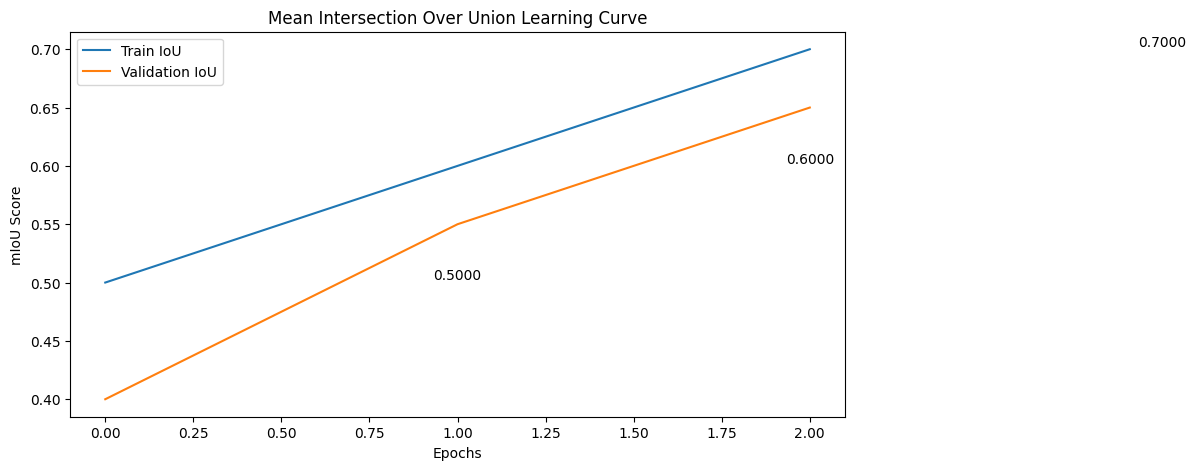

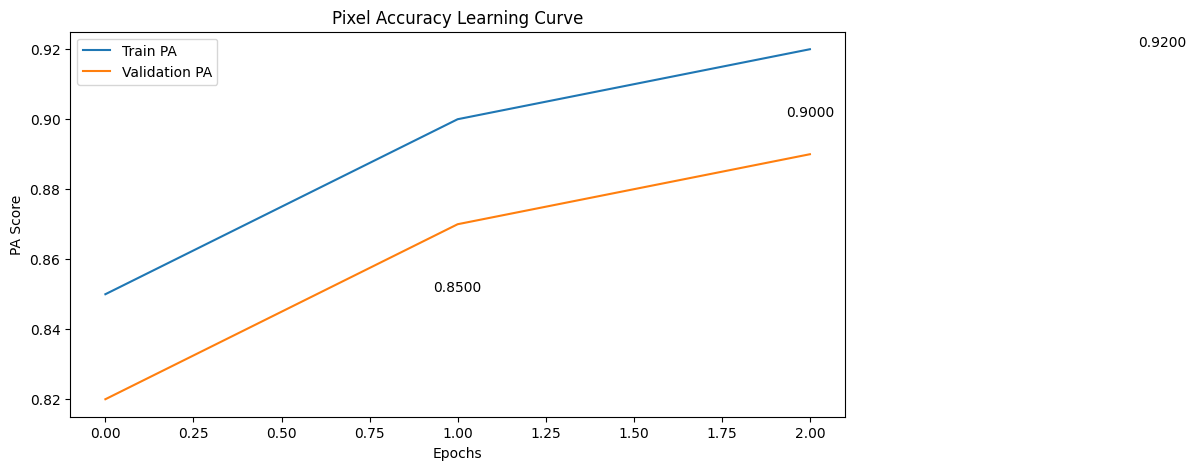

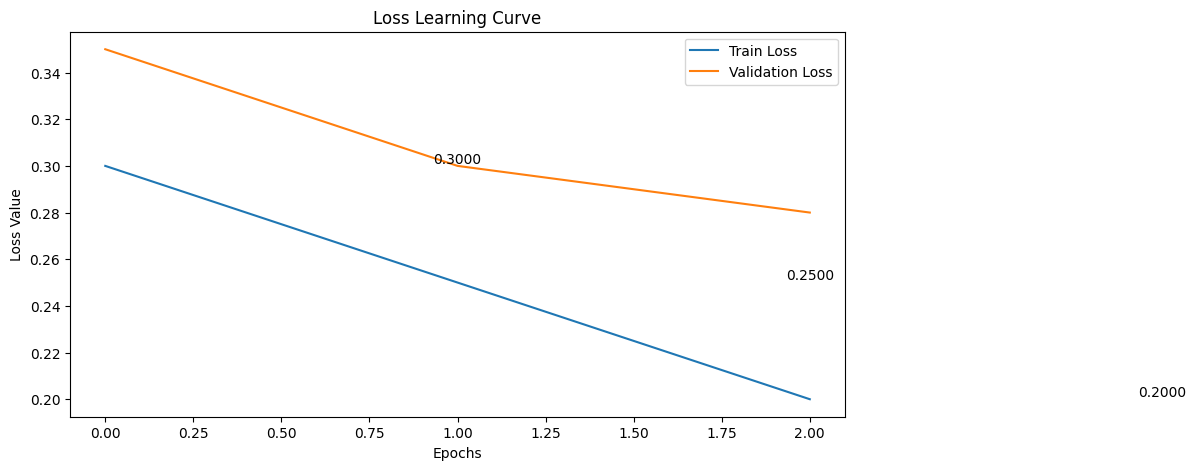

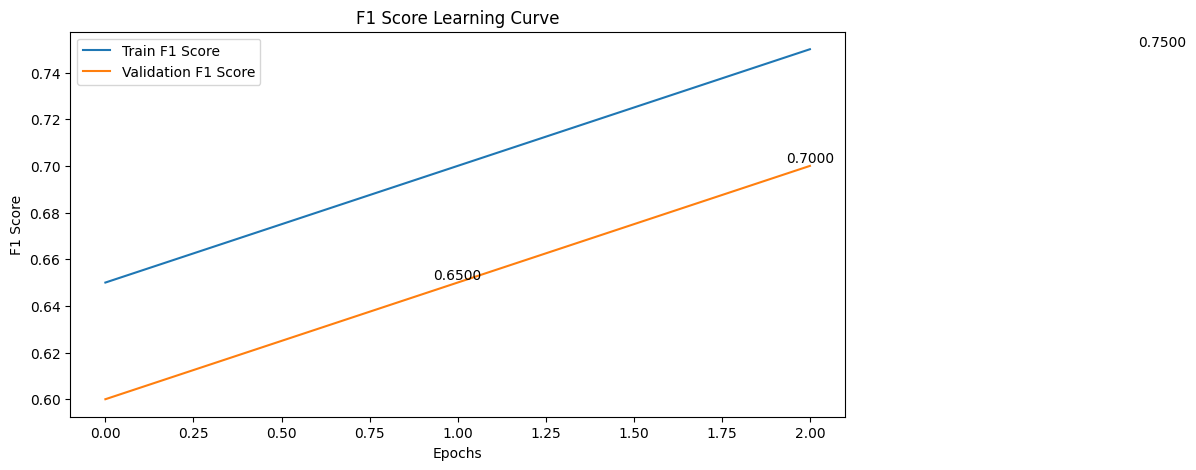

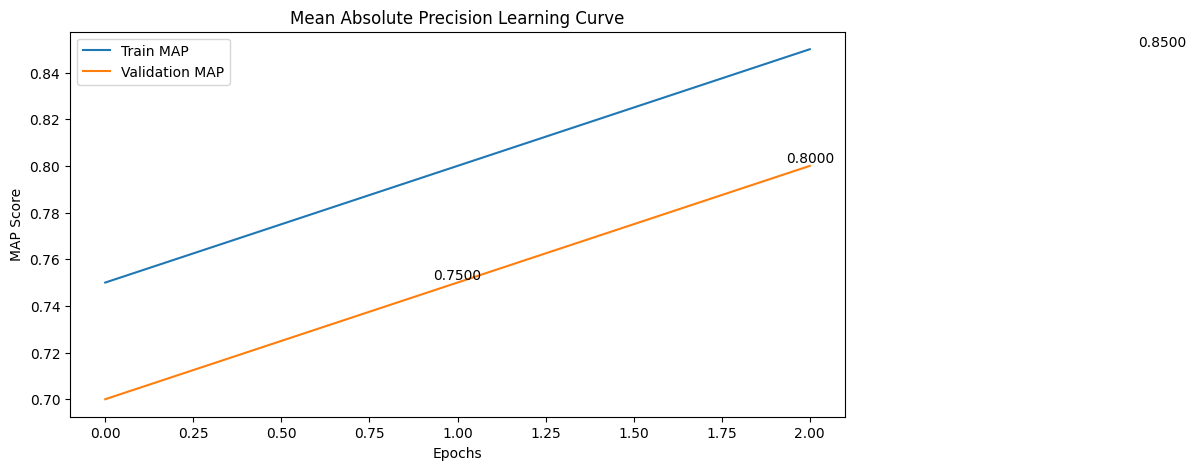

In [ ]:
import matplotlib.pyplot as plt

class Plot():
    def __init__(self, res):
        self.res = res

        # Existing visualizations
        self.visualize(metric1="tr_iou", metric2="val_iou", label1="Train IoU",
                       label2="Validation IoU", title="Mean Intersection Over Union Learning Curve", ylabel="mIoU Score")

        self.visualize(metric1="tr_pa", metric2="val_pa", label1="Train PA",
                       label2="Validation PA", title="Pixel Accuracy Learning Curve", ylabel="PA Score")

        self.visualize(metric1="tr_loss", metric2="val_loss", label1="Train Loss",
                       label2="Validation Loss", title="Loss Learning Curve", ylabel="Loss Value")

        # Add F1 Score and MAP visualizations
        self.visualize(metric1="tr_f1", metric2="val_f1", label1="Train F1 Score",
                       label2="Validation F1 Score", title="F1 Score Learning Curve", ylabel="F1 Score")

        self.visualize(metric1="tr_map", metric2="val_map", label1="Train MAP",
                       label2="Validation MAP", title="Mean Absolute Precision Learning Curve", ylabel="MAP Score")

    def plot(self, metric, label):
        plt.plot(self.res[metric], label=label)

    def decorate(self, ylabel, title, metric_values):
        plt.title(title)
        plt.xlabel("Epochs")
        plt.ylabel(ylabel)
        plt.legend()

        # Display numerical values above the data points
        for epoch, value in enumerate(metric_values, 1):
            plt.text(epoch, value, f'{value:.4f}', ha='center', va='bottom')

        plt.show()

    def visualize(self, metric1, metric2, label1, label2, title, ylabel):
        plt.figure(figsize=(10, 5))
        self.plot(metric1, label1)
        self.plot(metric2, label2)
        self.decorate(ylabel, title, self.res[metric1])

# Sample data including F1 scores and MAP scores
history = {
    "tr_iou": [0.5, 0.6, 0.7],
    "val_iou": [0.4, 0.55, 0.65],
    "tr_pa": [0.85, 0.9, 0.92],
    "val_pa": [0.82, 0.87, 0.89],
    "tr_loss": [0.3, 0.25, 0.2],
    "val_loss": [0.35, 0.3, 0.28],
    "tr_f1": [0.65, 0.7, 0.75],  # Sample F1 scores for training
    "val_f1": [0.6, 0.65, 0.7],   # Sample F1 scores for validation
    "tr_map": [0.75, 0.8, 0.85],  # Sample MAP scores for training
    "val_map": [0.7, 0.75, 0.8]   # Sample MAP scores for validation
}
# Create an instance of the Plot class
plotter = Plot(history)
